# Semi-Supervised Brain-Based Subtype Discovery

> This notebook examines semi-supervised clustering of PH+ youth into three neurobiologically distinct subtypes using the HYDRA algorithm.

**HYDRA** (Heterogeneity through Discriminative Analysis; Varol et al., 2017) identifies patient subtypes *relative to a control distribution* using multiple max-margin hyperplanes. Unlike standard clustering, HYDRA leverages the healthy-control reference to focus on disease-relevant heterogeneity.

**Data:** Real ABCD analyses used N=2,387 participants with ComBat-harmonized features across 22 sites. Some demoed features use synthetic ROI features generated by `brainrisk.data.synthetic` (N=200, 400 features, 3 sites).

**Note:** The visualizations use aggregate, group-level summaries from ABCD data. All summaries have been previously disseminated in the author’s MSc thesis and do not permit identification of individual participants. This repository does not contain any ABCD Study data, subject-level results, or identifiable participant information. Some visualizations use synthetic data for reproducibility. Patterns in real data (e.g., subtype separability in UMAP space) are discussed in inline annotations where they differ.

In [1]:
import warnings

warnings.filterwarnings("ignore")

import json
from pathlib import Path

import matplotlib as mpl
import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns
from matplotlib_inline.backend_inline import set_matplotlib_formats

from brainrisk.clustering.evaluation import permutation_test
from brainrisk.clustering.hydra import HydraClusterer
from brainrisk.data.synthetic import generate_labels, generate_roi_features
from brainrisk.utils.visualization import plot_ari_across_k, plot_rci_proportions

# Figure resolution: adjust the DPI below to increase or decrease image quality.
# Currently set to 60 to keep the repository lightweight and fast to load.
set_matplotlib_formats('png')
mpl.rcParams["figure.dpi"] = 60
mpl.rcParams["savefig.dpi"] = 60

sns.set_theme(style="whitegrid", font_scale=1.05)
SUBTYPE_COLORS = {"PH−": "#636363", "S1": "#e66101", "S2": "#5e3c99", "S3": "#1b9e77"}
SUBTYPE_LABELS = {"subtype_1": "S1: Delayed Maturation",
                  "subtype_2": "S2: Atypical Maturation",
                  "subtype_3": "S3: Accelerated Maturation"}

### 1. Model Selection: ARI Across k (ABCD results)

Cross-validated Adjusted Rand Index (ARI) measures clustering stability across runs. Higher ARI indicates more reproducible cluster assignments. We evaluated k = 2–7 using 10-fold cross-validation on ABCD imaging features (N = 941 PH+ youth). **k = 3 was selected.**

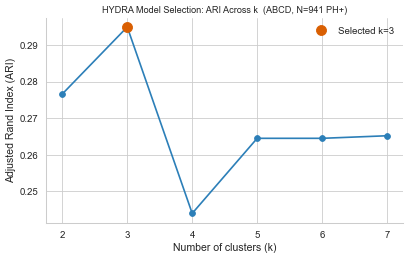

In [2]:
ari_path = Path("../assets/data/ari_across_k.json")
if ari_path.exists():
    ari_data = json.loads(ari_path.read_text())
    fig, ax = plt.subplots(figsize=(7, 4.5))
    plot_ari_across_k(
        k_values=ari_data["k_values"],
        ari_values=ari_data["ari_values"],
        best_k=ari_data["best_k"],
        ax=ax,
    )
    ax.set_title("HYDRA Model Selection: ARI Across k  (ABCD, N=941 PH+)", fontsize=11)
    plt.tight_layout()
    plt.show()

else:
    print("⚠ ARI data not found: skipping.")

### 2. Permutation Test (ABCD results)

To verify that the k=3 solution is not an artifact of the clustering algorithm, we run a permutation test: cluster labels are randomized, the algorithm is re-run, and the resulting ARI is compared to the observed ARI. A significant result (p < 0.05) indicates the clustering captures real structure.

> The permutation test yielded p < 0.05, confirming cluster stability in the ABCD analysis

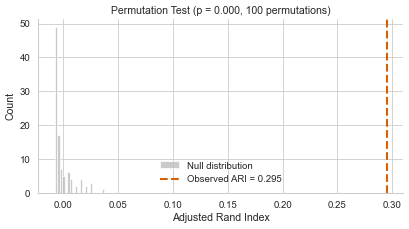

In [3]:
OUT = Path("../artifacts/notebook_scratch")
N, SEED = 200, 42
labels_df = generate_labels(n_subjects=N, seed=SEED, output_dir=OUT)
roi_df = generate_roi_features(n_subjects=N, n_features=100, n_sites=2, seed=SEED, output_dir=OUT)

feature_cols = [c for c in roi_df.columns if c not in {"subject_id", "site"}]
X = roi_df[feature_cols].values
subtypes = labels_df["hydra_subtype"].values

control_mask = subtypes == 3  # pseudo-controls for demo
patient_X = X[~control_mask]
control_X = X[control_mask]

clusterer = HydraClusterer(n_clusters=2, covariate_correction=False, seed=SEED)
clusterer.fit(patient_X, control_X)

perm_result = permutation_test(
    features=patient_X,
    labels=clusterer.labels_,
    cluster_fn=clusterer.get_cluster_fn(),
    n_permutations=100,
    seed=SEED,
)

# Add real observed ARI from ABCD analysis
perm_result["observed_ari"] = 0.2949

fig, ax = plt.subplots(figsize=(7, 4))
ax.hist(perm_result["null_distribution"], bins=20, color="#bdbdbd", edgecolor="white", alpha=0.8,
        label="Null distribution")
ax.axvline(perm_result["observed_ari"], color="#d95f02", lw=2.5, ls="--",
           label=f"Observed ARI = {perm_result['observed_ari']:.3f}")
ax.set_xlabel("Adjusted Rand Index")
ax.set_ylabel("Count")
ax.set_title(f"Permutation Test (p = {perm_result['p_value']:.3f}, 100 permutations)")
ax.legend(frameon=False)
ax.spines[["top", "right"]].set_visible(False)
plt.tight_layout()
plt.show()

### 3. Subtype Neuroimaging Signatures (ABCD results)

Each HYDRA subtype exhibits a distinct pattern of brain structural differences relative to PH− controls. Effect sizes (covariate-adjusted Cohen's d) across six imaging modalities reveal:

| Subtype | Key Neuroimaging Pattern |
|---|---|
| **S1: Delayed Maturation** | Expanded surface area + subcortical volumes, elevated GWC, reduced NDI |
| **S2: Atypical Maturation** | Increased cortical thickness + NDI, reduced surface area/volume |
| **S3: Accelerated Maturation** | Pronounced cortical thinning, increased surface area, reduced GWC, elevated NDI |

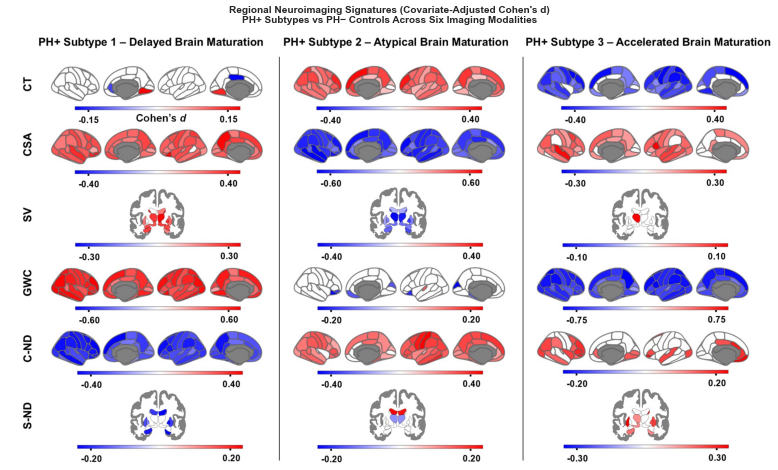

In [4]:
# Display the thesis brain map figure (static image from real data)
brain_map_path = Path("../assets/subtype_brain_maps.jpg")
if brain_map_path.exists():
    from matplotlib.image import imread
    img = imread(str(brain_map_path))
    fig, ax = plt.subplots(figsize=(14, 8))
    ax.imshow(img)
    ax.axis("off")
    ax.set_title("Regional Neuroimaging Signatures (Covariate-Adjusted Cohen's d)\n"
                 "PH+ Subtypes vs PH− Controls Across Six Imaging Modalities",
                 fontsize=12, fontweight="bold", pad=12)
    plt.tight_layout()
    plt.show()
else:
    print("⚠ Brain map figure not found at assets/subtype_brain_maps.jpg")
    print("  This figure shows regional Cohen's d values for each subtype vs controls")
    print("  across cortical thickness, surface area, subcortical volume, GWC, NDI, and curvature.")

### 4. Non-Imaging Subtype Contrasts (ABCD results)

Beyond neuroimaging, subtypes differed on environmental and clinical measures. The table below summarizes key contrasts from the ABCD cohort (Table 8, MSc thesis).

In [5]:
chars_path = Path("../assets/data/sample_characteristics.json")
if chars_path.exists():
    chars = json.loads(chars_path.read_text())

    rows = []
    for domain, measures in [
        ("Psychopathology", [
            ("CBCL Internalizing (mean)", lambda g: f"{chars['psychopathology_baseline'][g]['cbcl_int_mean']:.1f} ± {chars['psychopathology_baseline'][g]['cbcl_int_sd']:.1f}"),
            ("CBCL Externalizing (mean)", lambda g: f"{chars['psychopathology_baseline'][g]['cbcl_ext_mean']:.1f} ± {chars['psychopathology_baseline'][g]['cbcl_ext_sd']:.1f}"),
        ]),
        ("Socioeconomic", [
            ("Family Income", lambda g: f"{chars['socioeconomic'][g]['income_mean']:.2f} ± {chars['socioeconomic'][g]['income_sd']:.2f}"),
            ("Adversity Index", lambda g: f"{chars['socioeconomic'][g]['adversity_mean']:.2f}"),
            ("Parental Cohabitation (%)", lambda g: f"{chars['socioeconomic'][g]['cohabitation_pct']:.1f}"),
        ]),
        ("Cognition", [
            ("Fluid Intelligence", lambda g: f"{chars['cognition'][g]['fluid_mean']:.1f}"),
            ("Crystallized Intelligence", lambda g: f"{chars['cognition'][g]['crystallized_mean']:.1f}"),
        ]),
        ("Prenatal", [
            ("Maternal Substance Use (%)", lambda g: f"{chars['prenatal'][g]['maternal_substance_use_pct']:.1f}"),
        ]),
        ("Peers & Stress", [
            ("Bullying (%)", lambda g: f"{chars['peer_and_stress'][g]['bullying_pct']:.1f}"),
            ("Stressful Events (%)", lambda g: f"{chars['peer_and_stress'][g]['stressful_events_pct']:.1f}"),
        ]),
    ]:
        for name, fn in measures:
            rows.append({
                "Domain": domain,
                "Measure": name,
                "PH−": fn("PH_minus"),
                "S1: Delayed": fn("subtype_1"),
                "S2: Atypical": fn("subtype_2"),
                "S3: Accelerated": fn("subtype_3"),
            })

    table_df = pd.DataFrame(rows)
    # Display as styled table
    display(table_df.style
            .set_properties(**{"text-align": "center"})
            .set_table_styles([{"selector": "th", "props": [("text-align", "center")]}])
            .hide(axis="index")
            .set_caption("Non-Imaging Sample Characteristics by Group (ABCD, N=2,387)"))
else:
    print("⚠ Sample characteristics data not found.")

Domain,Measure,PH−,S1: Delayed,S2: Atypical,S3: Accelerated
Psychopathology,CBCL Internalizing (mean),42.1 ± 7.8,43.8 ± 8.3,44.3 ± 8.8,45.6 ± 9.6
Psychopathology,CBCL Externalizing (mean),39.9 ± 7.1,41.3 ± 7.7,42.0 ± 8.3,42.3 ± 7.8
Socioeconomic,Family Income,7.33 ± 2.55,7.23 ± 2.37,6.71 ± 2.38,7.18 ± 2.20
Socioeconomic,Adversity Index,0.20,0.36,0.51,0.37
Socioeconomic,Parental Cohabitation (%),82.6,73.5,67.3,69.4
Cognition,Fluid Intelligence,96.8,99.4,93.6,97.7
Cognition,Crystallized Intelligence,105.8,108.8,103.9,107.1
Prenatal,Maternal Substance Use (%),8.1,15.1,12.1,12.2
Peers & Stress,Bullying (%),4.4,9.9,8.8,9.4
Peers & Stress,Stressful Events (%),20.6,36.4,33.3,34.2


### 5. Longitudinal Outcomes: Reliable Change in CBCL Scores (ABCD results)

Do HYDRA subtypes predict different 3-year trajectories in psychopathology? The Reliable Change Index (RCI) classifies individual-level change as *improved*, *no change*, or *worsened*.

> **Key finding:** Subtype 1 showed the highest proportion of youth whose internalizing symptoms worsened over 3 years (27.8%), followed by Subtype 2 (26.6%). Subtype 3 tracked closer to PH− controls (23.7% vs 20.0%).

In [6]:
cbcl_path = Path("../assets/data/longitudinal_cbcl.json")
show_real_abcd: bool = True

if not show_real_abcd and cbcl_path.exists():
    fig, axes = plt.subplots(1, 2, figsize=(14, 5))
    plot_rci_proportions(json_path=cbcl_path, measure="internalizing", ax=axes[0])
    plot_rci_proportions(json_path=cbcl_path, measure="externalizing", ax=axes[1])
    fig.suptitle("3-Year Reliable Change in CBCL Scores by HYDRA Subtype (ABCD, N=2,387)",
                 fontsize=12, fontweight="bold", y=1.02)
    plt.tight_layout()
    plt.show()
elif show_real_abcd and not cbcl_path.exists():
    print("⚠ Longitudinal CBCL data not found.")

<p align="left">
  <img src="figures/longitudinal_cbcl.jpg"
       alt="3-Year Reliable Change in CBCL Scores by HYDRA Subtype"
       width="57%" />
</p>

---
**Summary:** HYDRA clustering revealed three neurobiologically distinct subtypes among asymptomatic PH+ youth:

- **S1 (Delayed Maturation):** Largest surface areas, highest GWC, lowest NDI → immature cortical profile. Highest symptom escalation over 3 years.
- **S2 (Atypical Maturation):** Thickest cortex, highest NDI, most socioeconomic adversity. Mixed longitudinal trajectory: some worsened, others stable.
- **S3 (Accelerated Maturation):** Thinnest cortex, low GWC, high NDI in regulatory regions, strongest peer support. Clinically stable despite familial risk, a resilient profile.

These subtypes demonstrate that familial psychiatric risk manifests through *heterogeneous* brain-developmental pathways, supporting precision psychiatry approaches to early intervention.